**Importing Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

**Loading Raw Datasets**

In [2]:
assessments=pd.read_csv('assessments.csv')
courses=pd.read_csv('courses.csv')
studentassessments=pd.read_csv('studentAssessment.csv')
studentinfo=pd.read_csv('studentInfo.csv')
studentregistrations=pd.read_csv('studentRegistration.csv')
studentvle=pd.read_csv('studentVle.csv')
vle=pd.read_csv('vle.csv')

In [3]:
df=pd.read_csv('encoded_unsupervised.csv')

In [4]:
df.columns

Index(['highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts',
       'studied_credits', 'date_registration', 'avg_clicks_per_day',
       'module_presentation_length', 'tma_cma_weighted_score',
       'total_submissions', 'late_submissions_count', 'avg_submission_delay',
       'sites_revisit_ratio', 'activity_diversity_ratio', 'code_module_BBB',
       'code_module_CCC', 'code_module_DDD', 'code_module_EEE',
       'code_module_FFF', 'code_module_GGG', 'code_presentation_2013J',
       'code_presentation_2014B', 'code_presentation_2014J', 'gender_M',
       'disability_Y'],
      dtype='object')

In [5]:
n_cols = len(df.columns)
print("Number of columns:", n_cols)

Number of columns: 25


In [6]:
import numpy as np

# df = your current feature-engineered dataset

eps = 1e-6  # prevents divide-by-zero

# 1) Late submission ratio (time-management discipline)
df['late_submission_ratio'] = df['late_submissions_count'] / (df['total_submissions'] + eps)

# 2) On-time submission ratio (reliability)
df['on_time_submission_ratio'] = 1 - df['late_submission_ratio']

# 3) Submissions per week (assessment consistency)
df['submissions_per_week'] = df['total_submissions'] / (df['module_presentation_length'] / 7 + eps)

# 4) Late submissions per week (chronic procrastination)
df['late_per_week'] = df['late_submissions_count'] / (df['module_presentation_length'] / 7 + eps)

# 5) Engagement per credit (effort relative to workload)
df['engagement_per_credit'] = df['avg_clicks_per_day'] / (df['studied_credits'] + eps)

# 6) Score per submission (efficiency of attempts)
df['score_per_submission'] = df['tma_cma_weighted_score'] / (df['total_submissions'] + eps)

# 7) Effort-to-score ratio (hard-working vs efficient learners)
df['effort_to_score_ratio'] = df['avg_clicks_per_day'] / (df['tma_cma_weighted_score'] + 1)

# 8) Procrastination index (severity of late behaviour)
df['procrastination_index'] = (
    df['late_submission_ratio'] * df['avg_submission_delay'].clip(lower=0)
)

# 9) Revision intensity (revision behaviour scaled by engagement)
df['revision_intensity'] = df['sites_revisit_ratio'] * df['avg_clicks_per_day']

# 10) Learning breadth score (diversity + engagement combined)
df['learning_breadth_score'] = df['activity_diversity_ratio'] * df['avg_clicks_per_day']

# Cleanup for clustering safety
new_cols = [
    'late_submission_ratio','on_time_submission_ratio','submissions_per_week','late_per_week',
    'engagement_per_credit','score_per_submission','effort_to_score_ratio','procrastination_index',
    'revision_intensity','learning_breadth_score'
]

df[new_cols] = df[new_cols].replace([np.inf, -np.inf], np.nan).fillna(0)

df[new_cols].head()


,late_submission_ratio,on_time_submission_ratio,submissions_per_week,late_per_week,engagement_per_credit,score_per_submission,effort_to_score_ratio,procrastination_index,revision_intensity,learning_breadth_score
0,-8.283661e+05,8.283671e+05,0.000000,-6.376980,0.255025,824000.0,0.419450,-0.000000e+00,-0.039385,0.283106
1,6.513253e+05,-6.513243e+05,0.000000,5.014073,132222.902941,654000.0,0.079941,0.000000e+00,0.060339,0.122355
2,1.325388e+00,-3.253879e-01,-4.811414,-6.376980,309506.981485,-0.0,0.309507,0.000000e+00,-0.038302,-0.081058
3,-8.283661e+05,8.283671e+05,0.000000,-6.376980,105179.523926,763000.0,0.059659,-0.000000e+00,0.153998,0.093302
4,1.584907e+06,-1.584906e+06,0.000000,12.201028,-147293.813167,550000.0,-0.095028,3.819731e+06,-0.095698,-0.085531


In [7]:
n_cols = len(df.columns)
print("Number of columns:", n_cols)

Number of columns: 35


In [8]:
df.head()

,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,date_registration,avg_clicks_per_day,module_presentation_length,tma_cma_weighted_score,total_submissions,...,late_submission_ratio,on_time_submission_ratio,submissions_per_week,late_per_week,engagement_per_credit,score_per_submission,effort_to_score_ratio,procrastination_index,revision_intensity,learning_breadth_score
0,0.75,1.000000,1.0,-0.368196,3.0,-1.818699,0.765076,0.909289,0.824,0.000,...,-8.283661e+05,8.283671e+05,0.000000,-6.376980,0.255025,824000.0,0.419450,-0.000000e+00,-0.039385,0.283106
1,0.75,0.222222,0.5,-0.368196,0.0,0.333158,0.132223,0.909289,0.654,0.000,...,6.513253e+05,-6.513243e+05,0.000000,5.014073,132222.902941,654000.0,0.079941,0.000000e+00,0.060339,0.122355
2,0.50,0.333333,0.5,-0.368196,0.0,-0.458563,0.309507,0.909289,0.000,-0.625,...,1.325388e+00,-3.253879e-01,-4.811414,-6.376980,309506.981485,-0.0,0.309507,0.000000e+00,-0.038302,-0.081058
3,0.50,0.555556,0.5,-0.368196,0.0,0.353459,0.105180,0.909289,0.763,0.000,...,-8.283661e+05,8.283671e+05,0.000000,-6.376980,105179.523926,763000.0,0.059659,-0.000000e+00,0.153998,0.093302
4,0.25,0.555556,0.0,-0.368196,0.0,-2.163809,-0.147294,0.909289,0.550,0.000,...,1.584907e+06,-1.584906e+06,0.000000,12.201028,-147293.813167,550000.0,-0.095028,3.819731e+06,-0.095698,-0.085531


In [9]:
df.columns

Index(['highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts',
       'studied_credits', 'date_registration', 'avg_clicks_per_day',
       'module_presentation_length', 'tma_cma_weighted_score',
       'total_submissions', 'late_submissions_count', 'avg_submission_delay',
       'sites_revisit_ratio', 'activity_diversity_ratio', 'code_module_BBB',
       'code_module_CCC', 'code_module_DDD', 'code_module_EEE',
       'code_module_FFF', 'code_module_GGG', 'code_presentation_2013J',
       'code_presentation_2014B', 'code_presentation_2014J', 'gender_M',
       'disability_Y', 'late_submission_ratio', 'on_time_submission_ratio',
       'submissions_per_week', 'late_per_week', 'engagement_per_credit',
       'score_per_submission', 'effort_to_score_ratio',
       'procrastination_index', 'revision_intensity',
       'learning_breadth_score'],
      dtype='object')

**Training**

In [10]:
final_features = [
    'avg_clicks_per_day',
    'activity_diversity_ratio',
    'sites_revisit_ratio',
    'late_submission_ratio',
    'avg_submission_delay',
    'procrastination_index',
    'total_submissions',
    'score_per_submission',
    'effort_to_score_ratio'
]

In [11]:
from sklearn.preprocessing import StandardScaler

X = df[final_features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


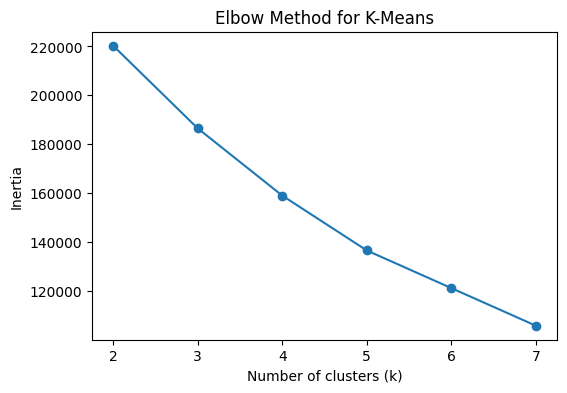

In [13]:
from sklearn.metrics import silhouette_score

for k in range(2, 8):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"k={k}, silhouette={score:.3f}")


k=2, silhouette=0.278
k=3, silhouette=0.321
k=4, silhouette=0.345
k=5, silhouette=0.325
k=6, silhouette=0.308
k=7, silhouette=0.310


In [31]:
# after scaling and after deciding k = 4
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)

df['cluster'] = kmeans_final.fit_predict(X_scaled)


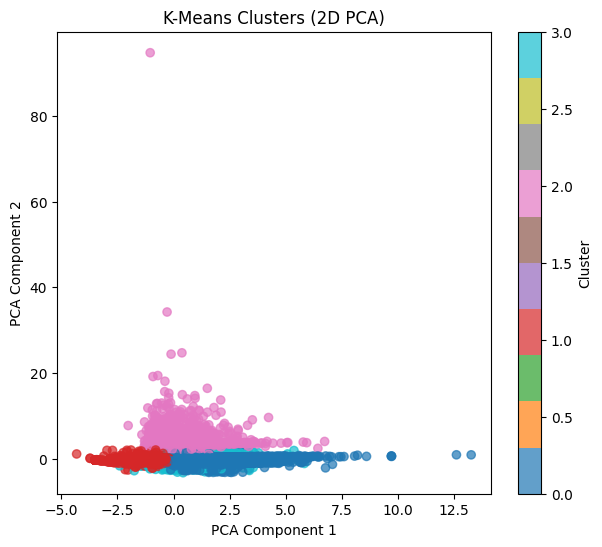

Explained variance (2D): 0.523068219106123


In [32]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca2 = PCA(n_components=2, random_state=42)
X_pca2 = pca2.fit_transform(X_scaled)

plt.figure(figsize=(7,6))
plt.scatter(
    X_pca2[:, 0],
    X_pca2[:, 1],
    c=df['cluster'],
    cmap='tab10',
    alpha=0.7
)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('K-Means Clusters (2D PCA)')
plt.colorbar(label='Cluster')
plt.show()

print("Explained variance (2D):", pca2.explained_variance_ratio_.sum())


umap

In [25]:
cluster_profile = df.groupby('cluster')[final_features].mean()
cluster_profile

,avg_clicks_per_day,activity_diversity_ratio,sites_revisit_ratio,late_submission_ratio,avg_submission_delay,procrastination_index,total_submissions,score_per_submission,effort_to_score_ratio
cluster,,,,,,,,,
0,0.429831,0.451107,0.555840,-8.551635e+02,-3.623804,30.205067,0.390540,1371.077136,0.307178
1,-0.660834,-0.442143,-0.647710,1.011400e+03,-0.025089,107.025024,-0.468622,2548.578627,-0.639018
2,0.288437,0.381563,0.439692,1.054044e+06,0.309672,594623.247751,0.000000,402153.191489,0.225383
3,0.376804,0.659542,0.282394,-5.968612e+05,-1.113897,4204.780831,0.000000,674899.252336,0.219320


In [26]:
cluster_profile_z = (cluster_profile - cluster_profile.mean()) / cluster_profile.std()
cluster_profile_z


,avg_clicks_per_day,activity_diversity_ratio,sites_revisit_ratio,late_submission_ratio,avg_submission_delay,procrastination_index,total_submissions,score_per_submission,effort_to_score_ratio
cluster,,,,,,,,,
0,0.622338,0.389331,0.726252,-0.167727,-1.409926,-0.504767,1.166685,-0.816767,0.624604
1,-1.490397,-1.454725,-1.468355,-0.165009,0.611135,-0.504508,-1.277763,-0.813190,-1.493953
2,0.348441,0.245763,0.514463,1.368300,0.799138,1.499968,0.055539,0.400711,0.441461
3,0.519618,0.819631,0.227640,-1.035565,-0.000347,-0.490692,0.055539,1.229246,0.427887


In [27]:
cluster_sizes = df['cluster'].value_counts().sort_index()
cluster_sizes


cluster
0    17938
1    11971
2     1034
3     1605
Name: count, dtype: int64